# 01 — Exploratory Data Analysis (EDA)
## BAMIS Fraud Detection | DATATHON ESP DATACLUB 2026

### Objectif
Comprendre la structure et la qualité des données avant toute modélisation.

### Plan
| Section | Contenu |
|---|---|
| 1 | Chargement & aperçu global |
| 2 | Qualité des données (nulls, types, doublons) |
| 3 | Distribution des statuts et services |
| 4 | Analyse des montants |
| 5 | Analyse temporelle (heure, jour, mois) |
| 6 | Analyse des acteurs (expéditeurs / destinataires) |
| 7 | Détection préliminaire d'anomalies |
| 8 | Synthèse & recommandations feature engineering |


In [1]:
import sys, warnings, os
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

os.makedirs('../reports/figures', exist_ok=True)

print(" Imports OK")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")


 Imports OK
   pandas  2.3.3
   numpy   2.2.6


---
## 1. Chargement & Aperçu Global

Le fichier brut fait **368 Mo / ~1,6 million de lignes**.  
On charge un **échantillon aléatoire de 30%** (seed=42) pour couvrir toute la période sans biais temporel.


In [2]:
import random
random.seed(42)

from src.data.preprocessing import _build_normalized_csv, COLUMNS_EXPECTED

DATA_PATH = Path('../src/data/DATASET_ESP-2026.csv')
SAMPLE_FRAC = 0.30   # 30% aléatoire

print(f"Taille fichier : {DATA_PATH.stat().st_size / 1e6:.1f} Mo")

# Step 1: Normalize the raw CSV (fix datetime commas + French decimal commas)
print("Normalisation du CSV en cours...")
norm_path = _build_normalized_csv(DATA_PATH)
print(f"CSV normalisé prêt : {norm_path.stat().st_size / 1e6:.1f} Mo")

# Step 2: Read with 30% sampling — keeps memory low
df_raw = pd.read_csv(
    norm_path,
    dtype=str,
    low_memory=False,
    index_col=False,
    skiprows=lambda i: i > 0 and random.random() > SAMPLE_FRAC,
    encoding='utf-8',
    encoding_errors='replace',
)
df_raw.columns = df_raw.columns.str.strip().str.upper()
norm_path.unlink(missing_ok=True)

print(f"Échantillon ALÉATOIRE chargé : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"(~{SAMPLE_FRAC*100:.0f}% du dataset — seed=42 reproductible)")

# Verify column alignment
assert list(df_raw.columns) == COLUMNS_EXPECTED, 'Column mismatch!'
print('Colonnes alignées correctement via le pipeline de preprocessing.')


Taille fichier : 385.6 Mo
Normalisation du CSV en cours...


CSV normalisé prêt : 384.0 Mo


Échantillon ALÉATOIRE chargé : 488,147 lignes × 23 colonnes
(~30% du dataset — seed=42 reproductible)
Colonnes alignées correctement via le pipeline de preprocessing.


In [3]:
# Aperçu des premières lignes
print("── Colonnes disponibles ──")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2}. {col}")


── Colonnes disponibles ──
   1. TRANSACTION_CODE
   2. SERVICE_CODE
   3. TRANSACTION_STATUS
   4. TRANSACTION_DATE
   5. TRANSACTION_AMOUNT
   6. REQUEST_REFERENCE
   7. REQUEST_DATE
   8. RESPONSE_DATE
   9. SOURCE_PHONE
  10. DESTINATION_PHONE
  11. TRANSACTION_FEES
  12. DESTINATION_TYPE
  13. PARTNER_REFERENCE
  14. BATCH_ID
  15. SOURCE_CUSTOMER
  16. DESTINATION_CUSTOMER
  17. TRANSACTION_DIRECTION
  18. QR_INDICATOR
  19. ACCOUNTING_RESPONSE_DATE
  20. ACCOUNTING_REQUEST_DATE
  21. SETTLEMENT_STATUS
  22. CHANNEL_TYPE
  23. LANGUAGE_CODE


In [4]:
df_raw.head(5)


,TRANSACTION_CODE,SERVICE_CODE,TRANSACTION_STATUS,TRANSACTION_DATE,TRANSACTION_AMOUNT,REQUEST_REFERENCE,REQUEST_DATE,RESPONSE_DATE,SOURCE_PHONE,DESTINATION_PHONE,TRANSACTION_FEES,DESTINATION_TYPE,PARTNER_REFERENCE,BATCH_ID,SOURCE_CUSTOMER,DESTINATION_CUSTOMER,TRANSACTION_DIRECTION,QR_INDICATOR,ACCOUNTING_RESPONSE_DATE,ACCOUNTING_REQUEST_DATE,SETTLEMENT_STATUS,CHANNEL_TYPE,LANGUAGE_CODE
0,2361,SERVICE_06,VALIDATED,12/06/22 16:00:02.395000000,200,NaN,12/06/22 16:00:02.395000000,12/06/22 16:00:02.475000000,TEL023599,TEL070804,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,2362,SERVICE_08,VALIDATED,12/06/22 18:52:41.884000000,10000,NaN,12/06/22 18:52:41.884000000,12/06/22 18:52:41.964000000,TEL070468,NaN,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,2363,SERVICE_06,VALIDATED,12/06/22 22:31:09.050000000,200,NaN,12/06/22 22:31:09.050000000,12/06/22 22:31:09.130000000,TEL106356,TEL025042,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,2367,SERVICE_06,VALIDATED,13/06/22 13:37:11.630000000,50,NaN,13/06/22 13:37:11.630000000,13/06/22 13:37:11.707000000,TEL170493,TEL170493,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
4,2369,SERVICE_10,VALIDATED,14/06/22 10:43:56.602000000,300,NaN,14/06/22 10:43:56.602000000,14/06/22 10:43:58.158000000,TEL137632,TEL121761,10,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN


---
## 2. Qualité des Données


In [5]:
# ── 2a. Valeurs nulles / vides ────────────────────────────────────────────
df_check = df_raw.copy()
# Remplacer chaînes vides par NaN
df_check = df_check.replace(r'^\s*$', np.nan, regex=True)

null_pct = df_check.isnull().mean().sort_values(ascending=False) * 100
null_df = pd.DataFrame({'null_%': null_pct.round(2), 'null_count': df_check.isnull().sum()})
print("Colonnes avec valeurs manquantes :")
print(null_df[null_df['null_%'] > 0].to_string())


Colonnes avec valeurs manquantes :
                          null_%  null_count
ACCOUNTING_REQUEST_DATE    50.85      248230
ACCOUNTING_RESPONSE_DATE   50.85      248230
BATCH_ID                   44.70      218183
CHANNEL_TYPE               96.43      470730
DESTINATION_CUSTOMER       38.65      188649
DESTINATION_PHONE           4.53       22114
DESTINATION_TYPE           89.44      436586
LANGUAGE_CODE             100.00      488135
PARTNER_REFERENCE          98.87      482617
QR_INDICATOR               14.43       70420
REQUEST_REFERENCE          38.63      188549
SOURCE_CUSTOMER            37.92      185104
TRANSACTION_DIRECTION      38.65      188649
TRANSACTION_FEES           20.35       99315


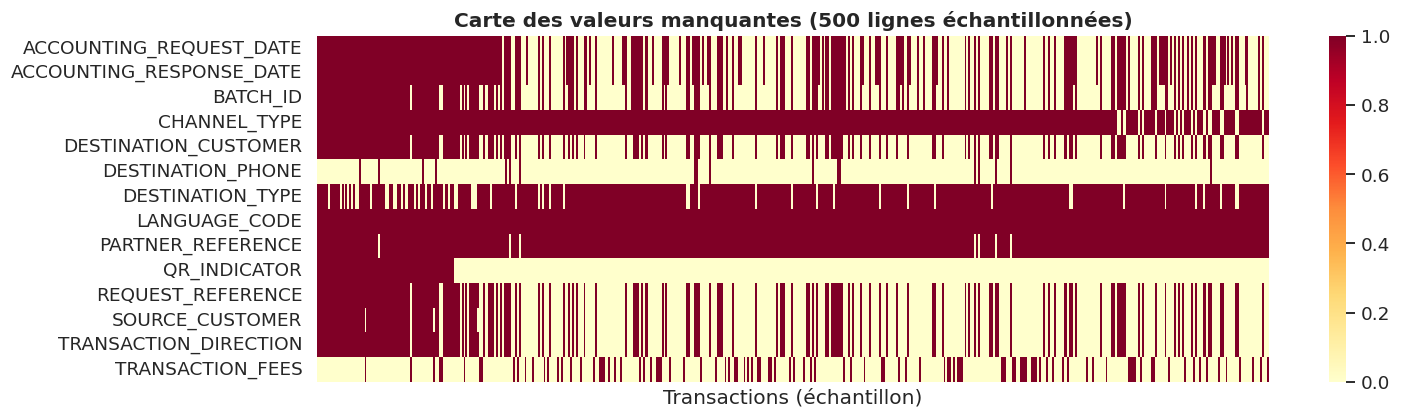

In [6]:
# ── 2b. Heatmap des valeurs nulles ────────────────────────────────────────
cols_with_nulls = null_df[null_df['null_%'] > 0].index.tolist()

fig, ax = plt.subplots(figsize=(14, 4))
null_matrix = df_check[cols_with_nulls].isnull().astype(int)
# Échantillon pour heatmap lisible
sample_idx = np.linspace(0, len(null_matrix)-1, min(500, len(null_matrix)), dtype=int)
sns.heatmap(null_matrix.iloc[sample_idx].T, ax=ax,
            cmap='YlOrRd', cbar=True, xticklabels=False, linewidths=0)
ax.set_title('Carte des valeurs manquantes (500 lignes échantillonnées)', fontweight='bold')
ax.set_xlabel('Transactions (échantillon)')
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', bbox_inches='tight')
plt.show()


In [7]:
# ── 2c. Doublons ──────────────────────────────────────────────────────────
dup_tx = df_check['TRANSACTION_CODE'].duplicated(keep=False).sum()
print(f"TRANSACTION_CODE doublons : {dup_tx:,}  ({dup_tx/len(df_check)*100:.3f}%)")

# Types effectifs après nettoyage
print("\n── Exemple valeurs par colonne ──")
for col in ['TRANSACTION_STATUS', 'SERVICE_CODE', 'CHANNEL_TYPE', 'DESTINATION_TYPE']:
    vals = df_check[col].dropna().unique()[:6]
    print(f"  {col:<30} : {list(vals)}")


TRANSACTION_CODE doublons : 0  (0.000%)

── Exemple valeurs par colonne ──
  TRANSACTION_STATUS             : ['VALIDATED', 'REJECTED', 'REGISTERED', 'INCOMPLETE', 'EXPIRED']
  SERVICE_CODE                   : ['SERVICE_06', 'SERVICE_08', 'SERVICE_10', 'SERVICE_04', 'SERVICE_12', 'SERVICE_09']
  CHANNEL_TYPE                   : ['C', 'A']
  DESTINATION_TYPE               : ['C', 'A']


---
## 3. Distribution des Statuts et Services


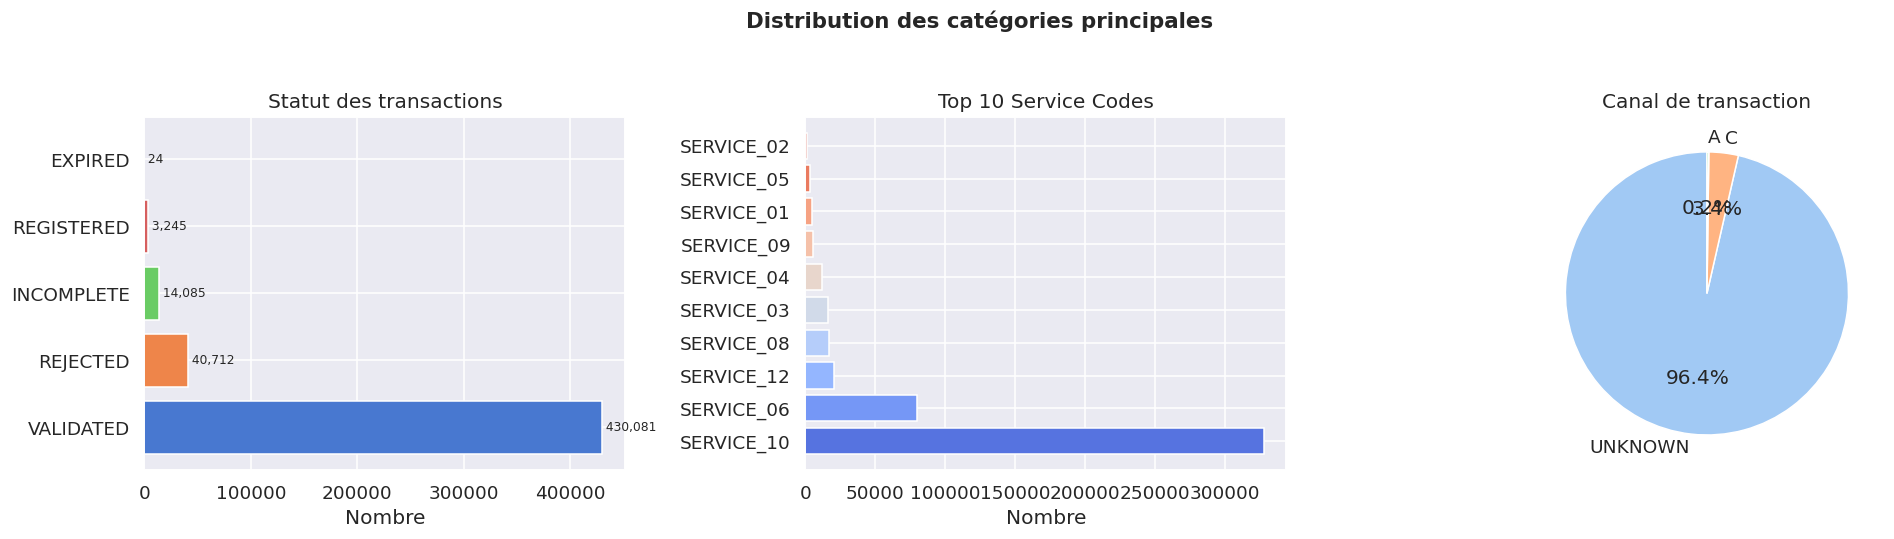


── Résumé statuts (top) ──
  VALIDATED                  430,081  (88.10%)
  REJECTED                    40,712  (8.34%)
  INCOMPLETE                  14,085  (2.89%)
  REGISTERED                   3,245  (0.66%)
  EXPIRED                         24  (0.00%)

Nombre de statuts distincts (brut) : 5
Nombre de canaux distincts (brut)  : 3


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution des catégories principales', fontsize=14, fontweight='bold')

# Transaction status (limité pour éviter surcharge de rendu)
status_series = (
    df_check['TRANSACTION_STATUS']
    .fillna('UNKNOWN')
    .astype(str)
    .str.strip()
    .replace('', 'UNKNOWN')
)
status_counts = status_series.value_counts()
TOP_STATUS = 12
status_plot = status_counts.head(TOP_STATUS).copy()
if len(status_counts) > TOP_STATUS:
    status_plot.loc['OTHER'] = status_counts.iloc[TOP_STATUS:].sum()

axes[0].barh(status_plot.index, status_plot.values,
             color=sns.color_palette('muted', len(status_plot)))
axes[0].set_title('Statut des transactions')
axes[0].set_xlabel('Nombre')
for i, v in enumerate(status_plot.values):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=8)

# Service code
svc_series = (
    df_check['SERVICE_CODE']
    .fillna('UNKNOWN')
    .astype(str)
    .str.strip()
    .replace('', 'UNKNOWN')
)
svc_counts = svc_series.value_counts().head(10)
axes[1].barh(svc_counts.index, svc_counts.values,
             color=sns.color_palette('coolwarm', len(svc_counts)))
axes[1].set_title('Top 10 Service Codes')
axes[1].set_xlabel('Nombre')

# Channel type (limité pour éviter pie chart trop chargé)
ch_series = (
    df_check['CHANNEL_TYPE']
    .fillna('UNKNOWN')
    .astype(str)
    .str.strip()
    .replace('', 'Interne ')
)
ch_counts = ch_series.value_counts()
TOP_CHANNEL = 6
ch_plot = ch_counts.head(TOP_CHANNEL).copy()
if len(ch_counts) > TOP_CHANNEL:
    ch_plot.loc['OTHER'] = ch_counts.iloc[TOP_CHANNEL:].sum()

if len(ch_plot):
    axes[2].pie(ch_plot.values, labels=ch_plot.index,
                autopct='%1.1f%%', startangle=90,
                colors=sns.color_palette('pastel', len(ch_plot)))
    axes[2].set_title('Canal de transaction')
else:
    axes[2].text(0.5, 0.5, 'Données non disponibles', ha='center', va='center')
    axes[2].set_title('Canal de transaction')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/01_categories.png', dpi=95)
plt.show()
plt.close(fig)

print("\n── Résumé statuts (top) ──")
for s, c in status_plot.items():
    print(f"  {s:<25} {c:>8,}  ({c/len(df_check)*100:.2f}%)")
print(f"\nNombre de statuts distincts (brut) : {len(status_counts):,}")
print(f"Nombre de canaux distincts (brut)  : {len(ch_counts):,}")


---
## 4. Analyse des Montants

Les montants sont stockés en **sous-unités XOF** (diviser par 1 000 000 pour obtenir des XOF).


In [9]:
# Conversion montants
df_check['AMOUNT_XOF'] = pd.to_numeric(
    df_check['TRANSACTION_AMOUNT'].str.strip().str.replace(r'[^\d.\-]','',regex=True),
    errors='coerce'
)
df_check['FEES_XOF'] = pd.to_numeric(
    df_check['TRANSACTION_FEES'].str.strip().str.replace(r'[^\d.\-]','',regex=True),
    errors='coerce'
)

# Detect extreme outliers (values > 10 billion are likely corrupt)
OUTLIER_THRESHOLD = 10_000_000_000
extreme_count = (df_check['AMOUNT_XOF'] > OUTLIER_THRESHOLD).sum()
print(f"── Statistiques TRANSACTION_AMOUNT (unités brutes) ──")
print(df_check['AMOUNT_XOF'].describe().apply(lambda x: f'{x:,.0f}').to_string())
if extreme_count > 0:
    print(f"\n⚠ {extreme_count} valeurs aberrantes détectées (> {OUTLIER_THRESHOLD:,}) — exclues des stats robustes ci-dessous")
    robust = df_check.loc[df_check['AMOUNT_XOF'] <= OUTLIER_THRESHOLD, 'AMOUNT_XOF']
    print(f"\n── Stats robustes (sans outliers) ──")
    print(robust.describe().apply(lambda x: f'{x:,.0f}').to_string())


── Statistiques TRANSACTION_AMOUNT (unités brutes) ──
count                                              488,147
mean     2,048,563,240,171,506,088,755,774,918,252,192,...
std      1,431,280,280,088,951,471,081,814,093,170,499,...
min                                                      0
25%                                                    100
50%                                                    700
75%                                                  3,300
max      1,000,000,000,000,000,127,793,096,885,319,003,...

⚠ 11 valeurs aberrantes détectées (> 10,000,000,000) — exclues des stats robustes ci-dessous

── Stats robustes (sans outliers) ──
count       488,136
mean          5,696
std         111,244
min               0
25%             100
50%             700
75%           3,300
max      41,397,588


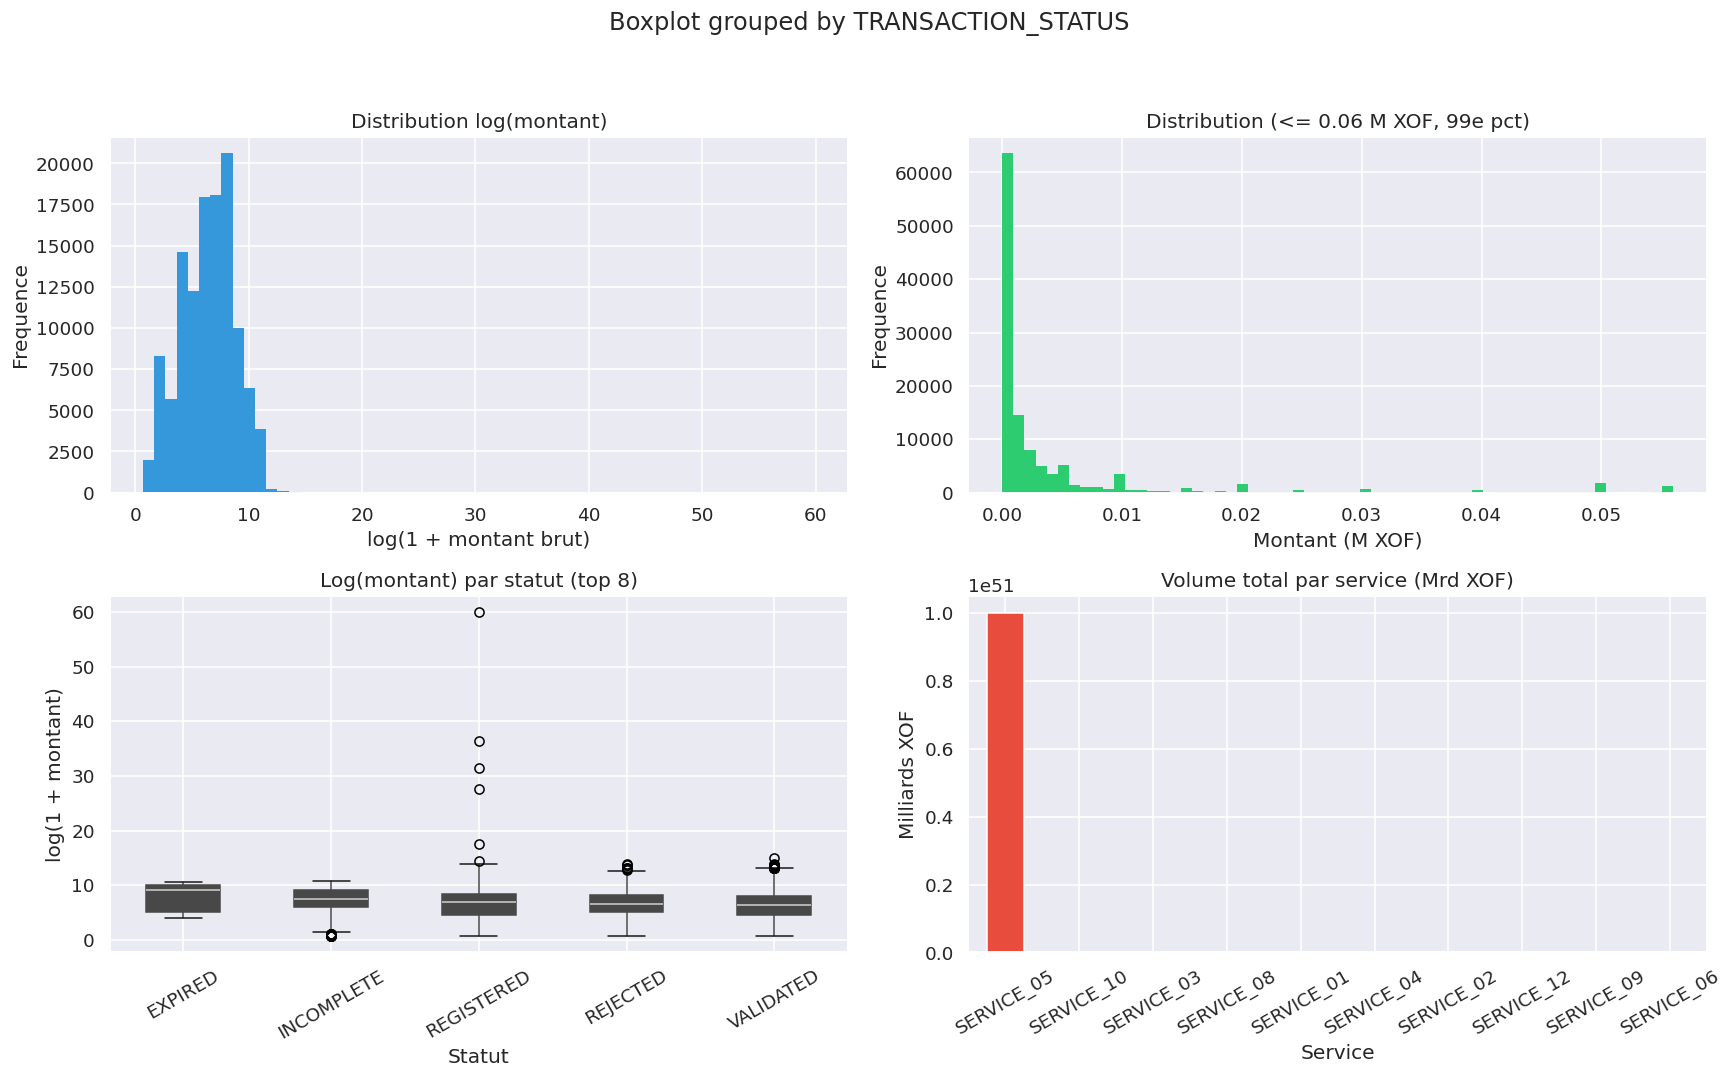

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse des montants de transactions (XOF)', fontsize=14, fontweight='bold')

amounts = df_check['AMOUNT_XOF'].dropna()
if len(amounts) > 120_000:
    amounts_plot = amounts.sample(120_000, random_state=42)
else:
    amounts_plot = amounts
amounts_m = amounts_plot / 1e6   # en millions XOF

# Distribution log
axes[0,0].hist(np.log1p(amounts_plot.clip(lower=0)), bins=60, color='#3498db', edgecolor='none')
axes[0,0].set_title('Distribution log(montant)')
axes[0,0].set_xlabel('log(1 + montant brut)')
axes[0,0].set_ylabel('Frequence')

# Distribution en millions XOF (99e percentile)
clip_val = amounts_m.quantile(0.99)
axes[0,1].hist(amounts_m.clip(upper=clip_val), bins=60, color='#2ecc71', edgecolor='none')
axes[0,1].set_title(f'Distribution (<= {clip_val:.2f} M XOF, 99e pct)')
axes[0,1].set_xlabel('Montant (M XOF)')
axes[0,1].set_ylabel('Frequence')

# Boxplot par statut (top statuts seulement)
status_ok = df_check.dropna(subset=['TRANSACTION_STATUS', 'AMOUNT_XOF']).copy()
if len(status_ok) > 150_000:
    status_ok = status_ok.sample(150_000, random_state=42)

top_status = status_ok['TRANSACTION_STATUS'].value_counts().head(8).index
status_ok = status_ok[status_ok['TRANSACTION_STATUS'].isin(top_status)].copy()
status_ok['log_amount'] = np.log1p(status_ok['AMOUNT_XOF'].clip(lower=0))
status_ok.boxplot(column='log_amount', by='TRANSACTION_STATUS', ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Log(montant) par statut (top 8)')
axes[1,0].set_xlabel('Statut')
axes[1,0].set_ylabel('log(1 + montant)')
axes[1,0].tick_params(axis='x', rotation=30)

# Montant cumule par service
svc_amount = (
    df_check.groupby('SERVICE_CODE')['AMOUNT_XOF']
    .sum().sort_values(ascending=False).head(10) / 1e9
)
svc_amount.plot(kind='bar', ax=axes[1,1], color='#e74c3c', edgecolor='white')
axes[1,1].set_title('Volume total par service (Mrd XOF)')
axes[1,1].set_xlabel('Service')
axes[1,1].set_ylabel('Milliards XOF')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/01_amounts.png', dpi=95)
plt.show()
plt.close(fig)


In [11]:
# Transactions à très hauts montants
HIGH = 1_000_000  # 1M en unités brutes
high_tx = df_check[df_check['AMOUNT_XOF'] > HIGH]
print(f"Transactions > 1 000 000 (unités brutes) : {len(high_tx):,}  ({len(high_tx)/len(df_check)*100:.2f}%)")
print(f"Montant max observé : {df_check['AMOUNT_XOF'].max():,.0f}")
print(f"Montant médian      : {df_check['AMOUNT_XOF'].median():,.0f}")


Transactions > 1 000 000 (unités brutes) : 22  (0.00%)
Montant max observé : 1,000,000,000,000,000,127,793,096,885,319,003,999,249,391,192,200,302,120,927,232
Montant médian      : 700


---
## 5. Analyse Temporelle


In [12]:
# Parse dates — truncate 9-digit microseconds to 6 digits for Python compatibility
tx_date_raw = df_check['TRANSACTION_DATE'].fillna('').astype(str).str.strip()

# Truncate fractional seconds to 6 digits (Python %f max)
tx_date_clean = tx_date_raw.str.replace(r'(\..{6})\d+', r'\1', regex=True)

# 1) Format principal observe dans le dataset
tx_date = pd.to_datetime(tx_date_clean, format='%d/%m/%y %H:%M:%S.%f', errors='coerce')

# 2) Fallback sur annee a 4 chiffres pour les rares variations
fallback_mask = tx_date.isna() & tx_date_raw.ne('')
if fallback_mask.any():
    tx_date_fallback = pd.to_datetime(
        tx_date_clean[fallback_mask],
        format='%d/%m/%Y %H:%M:%S.%f',
        errors='coerce'
    )
    tx_date.loc[fallback_mask] = tx_date_fallback

df_check['TX_DATE'] = tx_date
parse_mode = 'format=%d/%m/%y %H:%M:%S.%f (+fallback %Y)'

df_valid = df_check.dropna(subset=['TX_DATE']).copy()
df_valid['hour']  = df_valid['TX_DATE'].dt.hour
df_valid['dow']   = df_valid['TX_DATE'].dt.dayofweek
df_valid['month'] = df_valid['TX_DATE'].dt.month
df_valid['date']  = df_valid['TX_DATE'].dt.date

parse_rate = len(df_valid) / max(len(df_check), 1) * 100
print(f"Mode parsing retenu : {parse_mode}")
print(f"Dates valides        : {len(df_valid):,} / {len(df_check):,} ({parse_rate:.2f}%)")
print(f"Période couverte     : {df_valid['TX_DATE'].min()}  →  {df_valid['TX_DATE'].max()}")
print(f"Jours actifs         : {df_valid['date'].nunique():,}")
print(f"Transactions/jour (médiane) : {df_valid.groupby('date').size().median():.0f}")


Mode parsing retenu : format=%d/%m/%y %H:%M:%S.%f (+fallback %Y)
Dates valides        : 488,147 / 488,147 (100.00%)
Période couverte     : 2003-06-05 18:38:48.777000  →  2026-07-15 00:21:21.544000
Jours actifs         : 1,538
Transactions/jour (médiane) : 209


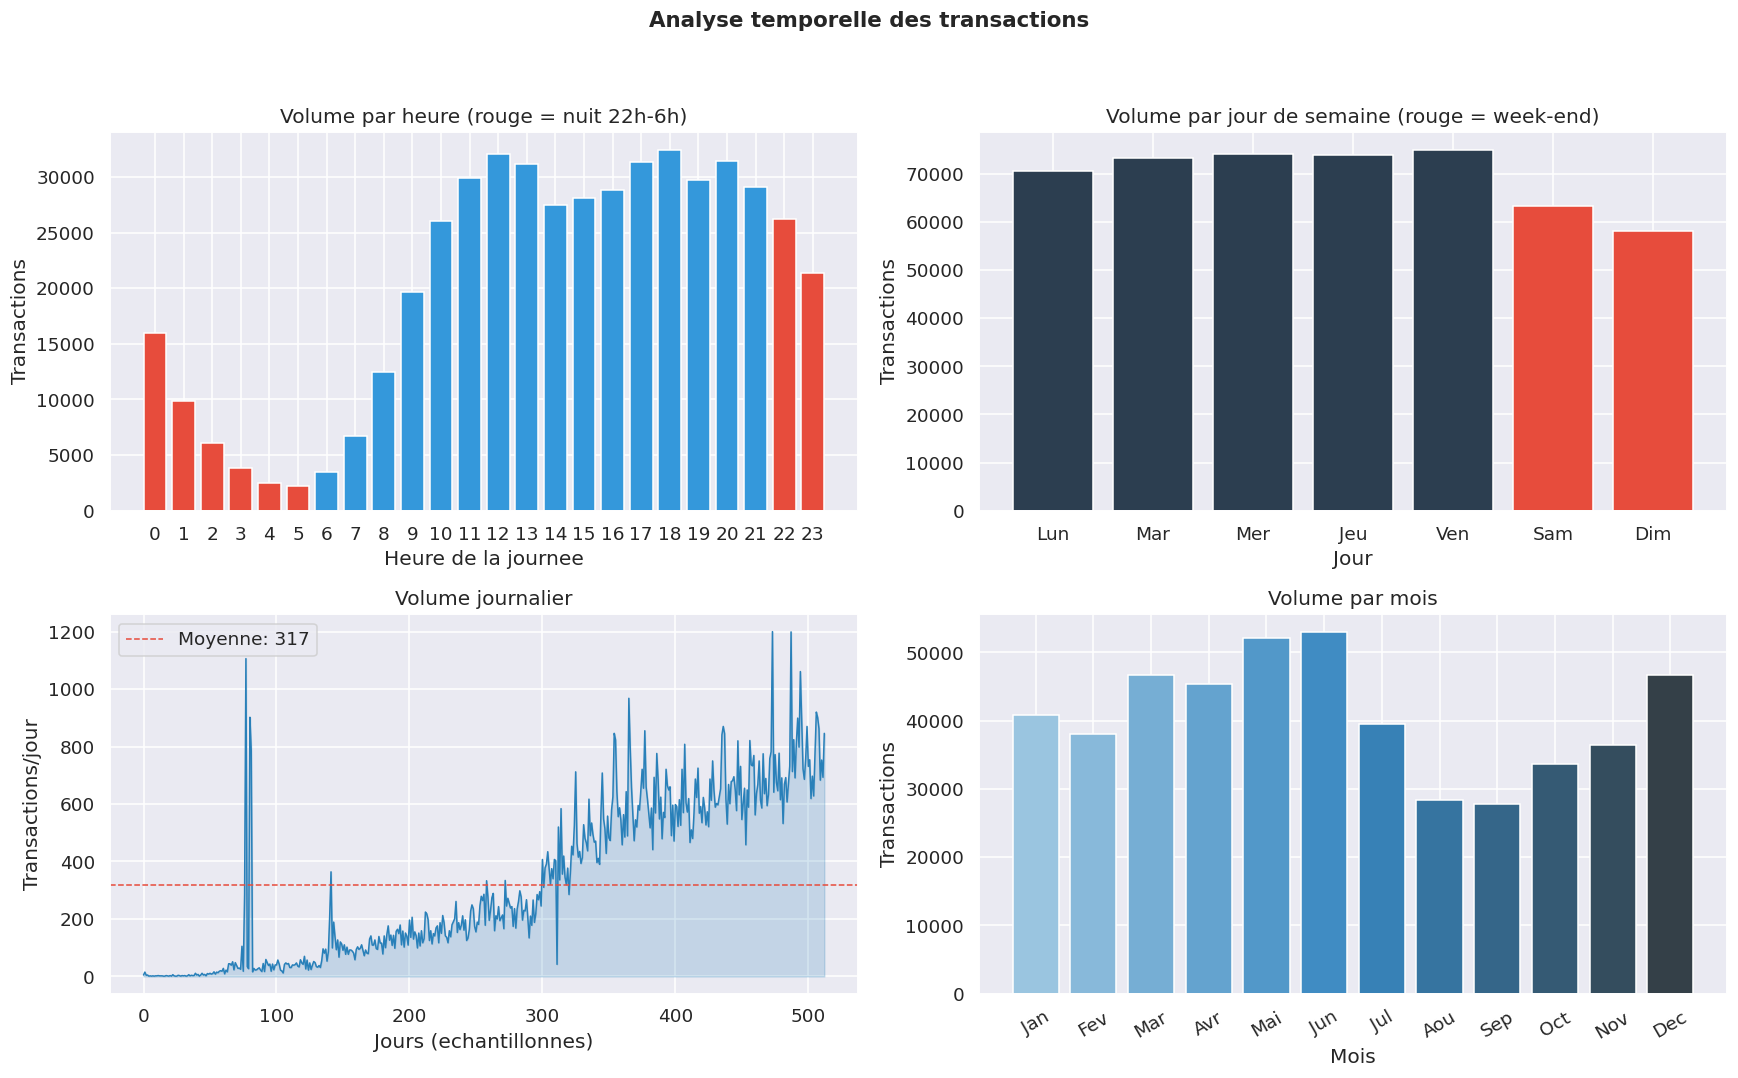


Transactions nocturnes (22h-6h) : 18.06%
Transactions week-end            : 24.86%


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analyse temporelle des transactions', fontsize=14, fontweight='bold')

day_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
month_labels = ['Jan','Fev','Mar','Avr','Mai','Jun','Jul','Aou','Sep','Oct','Nov','Dec']

# Volume horaire
hour_cnt = df_valid['hour'].value_counts().sort_index()
night_color = ['#e74c3c' if h >= 22 or h < 6 else '#3498db' for h in hour_cnt.index]
axes[0,0].bar(hour_cnt.index, hour_cnt.values, color=night_color)
axes[0,0].set_title('Volume par heure (rouge = nuit 22h-6h)')
axes[0,0].set_xlabel('Heure de la journee')
axes[0,0].set_ylabel('Transactions')
axes[0,0].set_xticks(range(0, 24))

# Volume par jour de semaine
dow_cnt = df_valid['dow'].value_counts().sort_index()
colors_dow = ['#e74c3c' if i >= 5 else '#2c3e50' for i in range(7)]
axes[0,1].bar([day_labels[i] for i in dow_cnt.index], dow_cnt.values,
               color=[colors_dow[i] for i in dow_cnt.index])
axes[0,1].set_title('Volume par jour de semaine (rouge = week-end)')
axes[0,1].set_xlabel('Jour')
axes[0,1].set_ylabel('Transactions')

# Volume journalier (downsample visuel si trop de points)
daily = df_valid.groupby('date').size()
if len(daily) > 400:
    step = max(1, len(daily) // 400)
    daily_plot = daily.iloc[::step]
else:
    daily_plot = daily

x = range(len(daily_plot))
axes[1,0].plot(x, daily_plot.values, color='#2980b9', linewidth=1)
axes[1,0].fill_between(x, daily_plot.values, alpha=0.2, color='#2980b9')
axes[1,0].set_title('Volume journalier')
axes[1,0].set_xlabel('Jours (echantillonnes)')
axes[1,0].set_ylabel('Transactions/jour')
axes[1,0].axhline(daily.mean(), color='#e74c3c', linestyle='--', linewidth=1,
                   label=f'Moyenne: {daily.mean():.0f}')
axes[1,0].legend()

# Volume mensuel
month_cnt = df_valid['month'].value_counts().sort_index()
axes[1,1].bar([month_labels[m-1] for m in month_cnt.index], month_cnt.values,
               color=sns.color_palette('Blues_d', len(month_cnt)))
axes[1,1].set_title('Volume par mois')
axes[1,1].set_xlabel('Mois')
axes[1,1].set_ylabel('Transactions')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/01_temporal.png', dpi=95)
plt.show()
plt.close(fig)

night_pct = ((df_valid['hour'] >= 22) | (df_valid['hour'] < 6)).mean() * 100
wknd_pct  = df_valid['dow'].isin([5,6]).mean() * 100
print(f"\nTransactions nocturnes (22h-6h) : {night_pct:.2f}%")
print(f"Transactions week-end            : {wknd_pct:.2f}%")


---
## 6. Analyse des Acteurs
> Qui envoie ? Qui reçoit ? Identifier les comportements extrêmes.


In [14]:
# Top expéditeurs par volume
top_senders = (
    df_check.groupby('SOURCE_PHONE')
    .agg(nb_tx=('TRANSACTION_CODE','count'),
         total_amount=('AMOUNT_XOF','sum'),
         unique_dest=('DESTINATION_PHONE','nunique'))
    .sort_values('nb_tx', ascending=False)
    .head(20)
    .reset_index()
)

print("Top 20 expéditeurs par nombre de transactions :")
print(top_senders.head(10).to_string(index=False))


Top 20 expéditeurs par nombre de transactions :
SOURCE_PHONE  nb_tx  total_amount  unique_dest
   TEL153382   3329    448,799.00           37
   TEL080205   2951     51,698.00           11
   TEL011583   1729 16,133,356.10          399
   TEL096060   1624 44,826,700.95         1056
   TEL108730   1562    531,137.20          115
   TEL096013   1328 28,700,422.80          515
   TEL096061   1327 70,845,602.95          727
   TEL026115   1264  6,913,638.00          366
   TEL096047   1148 32,075,269.00          576
   TEL096056   1124 56,321,068.50          499


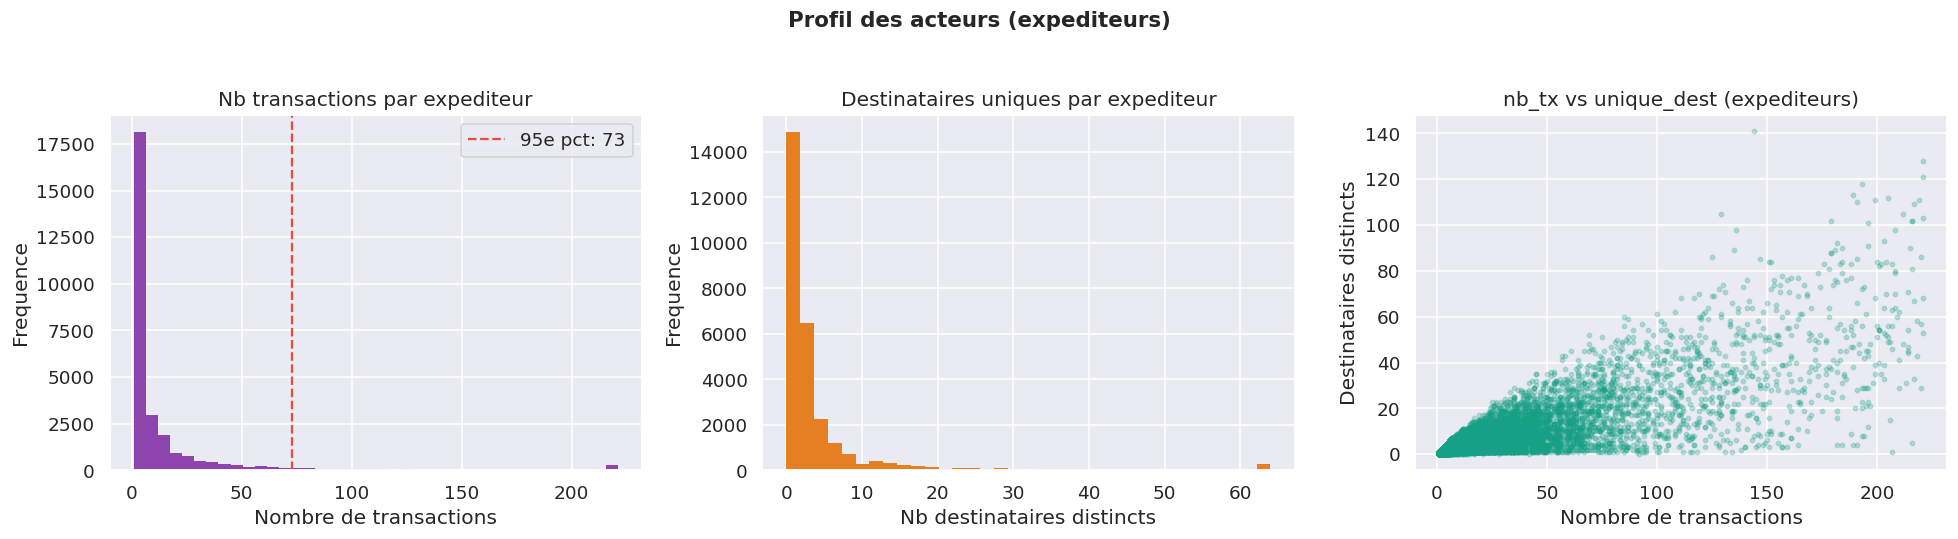


Statistiques expediteurs
  Expediteurs uniques             : 28,413
  Mediane transactions/expediteur : 3
  Max transactions (un seul)      : 3,329
  Expediteurs avec > 10 tx        : 7,737  (27.2%)
  Fan-out max (destinataires)     : 1,056


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Profil des acteurs (expediteurs)', fontsize=14, fontweight='bold')

sender_stats = (
    df_check.groupby('SOURCE_PHONE')
    .agg(nb_tx=('TRANSACTION_CODE','count'),
         total_amount=('AMOUNT_XOF','sum'),
         unique_dest=('DESTINATION_PHONE','nunique'))
)

# Distribution nb transactions par sender
nb_tx_clipped = sender_stats['nb_tx'].clip(upper=sender_stats['nb_tx'].quantile(0.99))
axes[0].hist(nb_tx_clipped, bins=40, color='#8e44ad', edgecolor='none')
axes[0].set_title('Nb transactions par expediteur')
axes[0].set_xlabel('Nombre de transactions')
axes[0].set_ylabel('Frequence')
axes[0].axvline(sender_stats['nb_tx'].quantile(0.95), color='#e74c3c',
                linestyle='--', label=f"95e pct: {sender_stats['nb_tx'].quantile(0.95):.0f}")
axes[0].legend()

# Distribution destinataires uniques (fan-out)
dest_clipped = sender_stats['unique_dest'].clip(upper=sender_stats['unique_dest'].quantile(0.99))
axes[1].hist(dest_clipped, bins=35, color='#e67e22', edgecolor='none')
axes[1].set_title('Destinataires uniques par expediteur')
axes[1].set_xlabel('Nb destinataires distincts')
axes[1].set_ylabel('Frequence')

# Correlation nb_tx vs unique_dest (sample pour rendu)
sample_senders = sender_stats[sender_stats['nb_tx'] <= sender_stats['nb_tx'].quantile(0.99)]
if len(sample_senders) > 40_000:
    sample_senders = sample_senders.sample(40_000, random_state=42)
axes[2].scatter(sample_senders['nb_tx'], sample_senders['unique_dest'],
                alpha=0.25, s=8, color='#16a085')
axes[2].set_title('nb_tx vs unique_dest (expediteurs)')
axes[2].set_xlabel('Nombre de transactions')
axes[2].set_ylabel('Destinataires distincts')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/01_actors.png', dpi=95)
plt.show()
plt.close(fig)

print(f"\nStatistiques expediteurs")
print(f"  Expediteurs uniques             : {len(sender_stats):,}")
print(f"  Mediane transactions/expediteur : {sender_stats['nb_tx'].median():.0f}")
print(f"  Max transactions (un seul)      : {sender_stats['nb_tx'].max():,}")
print(f"  Expediteurs avec > 10 tx        : {(sender_stats['nb_tx'] > 10).sum():,}  ({(sender_stats['nb_tx'] > 10).mean()*100:.1f}%)")
print(f"  Fan-out max (destinataires)     : {sender_stats['unique_dest'].max():,}")


---
## 6b. Matrice de Corrélation des Variables Numériques Brutes
>  on analyse les **relations linéaires entre les variables numériques existantes**.  
> Cela révèle les redondances et guide le feature engineering.


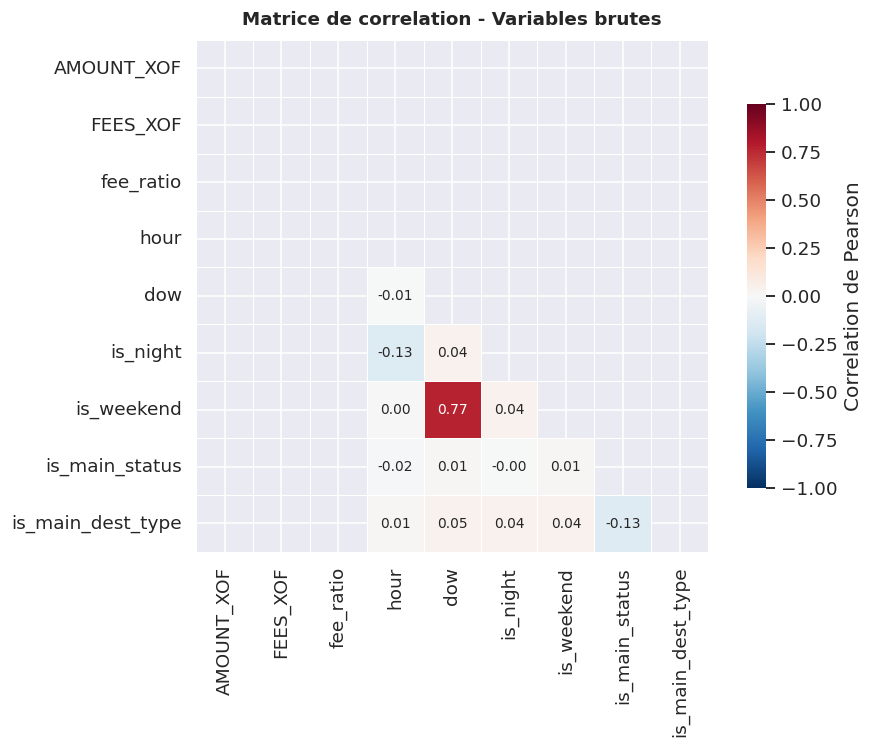

Statut principal utilise pour le flag is_main_status: VALIDATED
Destination principale utilisee pour is_main_dest_type: UNKNOWN
Top paires correlees (|r| decroissant) :
  dow                    x is_weekend              r = +0.766
  hour                   x is_night                r = -0.133
  is_main_status         x is_main_dest_type       r = -0.126
  dow                    x is_main_dest_type       r = +0.046
  is_weekend             x is_main_dest_type       r = +0.044
  is_night               x is_weekend              r = +0.042
  dow                    x is_night                r = +0.040
  is_night               x is_main_dest_type       r = +0.040


In [16]:
# Correlation des variables numeriques brutes
# On echantillonne pour accelerer les conversions + corr
if len(df_check) > 250_000:
    df_corr = df_check.sample(250_000, random_state=42).copy()
else:
    df_corr = df_check.copy()

df_corr['AMOUNT_XOF'] = pd.to_numeric(
    df_corr['TRANSACTION_AMOUNT'].str.strip().str.replace(r'[^\\d.\\-]','',regex=True),
    errors='coerce'
)
df_corr['FEES_XOF'] = pd.to_numeric(
    df_corr['TRANSACTION_FEES'].str.strip().str.replace(r'[^\\d.\\-]','',regex=True),
    errors='coerce'
)

if 'TX_DATE' not in df_corr.columns:
    tx_date_raw = df_corr['TRANSACTION_DATE'].fillna('').astype(str).str.strip()
    tx_date_clean = tx_date_raw.str.replace(r'(\..{6})\d+', r'\1', regex=True)
    tx_date = pd.to_datetime(tx_date_clean, format='%d/%m/%y %H:%M:%S.%f', errors='coerce')
    fallback_mask = tx_date.isna() & tx_date_raw.ne('')
    if fallback_mask.any():
        tx_date_fallback = pd.to_datetime(
            tx_date_clean[fallback_mask],
            format='%d/%m/%Y %H:%M:%S.%f',
            errors='coerce'
        )
        tx_date.loc[fallback_mask] = tx_date_fallback
    df_corr['TX_DATE'] = tx_date

df_corr['hour']       = df_corr['TX_DATE'].dt.hour
df_corr['dow']        = df_corr['TX_DATE'].dt.dayofweek
df_corr['is_night']   = ((df_corr['hour'] >= 22) | (df_corr['hour'] < 6)).astype(int)
df_corr['is_weekend'] = df_corr['dow'].isin([5, 6]).astype(int)
df_corr['fee_ratio']  = df_corr['FEES_XOF'] / df_corr['AMOUNT_XOF'].replace(0, np.nan)

# Flags derives des valeurs reelles presentes (pas d'hypothese de labels)
status_norm = df_corr['TRANSACTION_STATUS'].fillna('UNKNOWN').astype(str).str.strip()
dest_norm = df_corr['DESTINATION_TYPE'].fillna('UNKNOWN').astype(str).str.strip()
main_status = status_norm.value_counts().index[0]
main_dest_type = dest_norm.value_counts().index[0]
df_corr['is_main_status'] = (status_norm == main_status).astype(int)
df_corr['is_main_dest_type'] = (dest_norm == main_dest_type).astype(int)

NUM_COLS = [
    'AMOUNT_XOF', 'FEES_XOF', 'fee_ratio',
    'hour', 'dow', 'is_night', 'is_weekend',
    'is_main_status', 'is_main_dest_type',
]

corr_matrix = df_corr[NUM_COLS].astype(float).corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    linewidths=0.6,
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Correlation de Pearson'},
)
ax.set_title('Matrice de correlation - Variables brutes', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('../reports/figures/01_correlation_before_fe.png', dpi=95)
plt.show()
plt.close(fig)

print(f"Statut principal utilise pour le flag is_main_status: {main_status}")
print(f"Destination principale utilisee pour is_main_dest_type: {main_dest_type}")

corr_pairs = (
    corr_matrix.abs()
    .where(~np.tril(np.ones(corr_matrix.shape, dtype=bool)))
    .stack()
    .sort_values(ascending=False)
    .head(8)
)
print('Top paires correlees (|r| decroissant) :')
for (c1, c2), _ in corr_pairs.items():
    print(f"  {c1:<22} x {c2:<22}  r = {corr_matrix.loc[c1, c2]:+.3f}")


---
## 7. Détection Préliminaire d'Anomalies
> Avant tout modèle ML, des règles simples permettent de repérer des comportements suspects.


In [17]:
# ── Indicateurs d'anomalies simples ──────────────────────────────────────
df_valid_num = df_valid.copy()
df_valid_num['AMOUNT_XOF'] = pd.to_numeric(
    df_valid_num['TRANSACTION_AMOUNT'].str.strip().str.replace(r'[^\d.\-]','',regex=True),
    errors='coerce'
)

THRESHOLDS = [100_000, 500_000, 1_000_000]

for t in THRESHOLDS:
    lower = t * 0.9
    near = ((df_valid_num['AMOUNT_XOF'] >= lower) & (df_valid_num['AMOUNT_XOF'] < t)).sum()
    print(f"  Près du seuil {t:>10,} (±10%) : {near:>7,}  ({near/len(df_valid_num)*100:.3f}%)")

night_tx = ((df_valid_num['hour'] >= 22) | (df_valid_num['hour'] < 6)).sum()
print(f"\n  Transactions nocturnes (22h-6h) : {night_tx:>7,}  ({night_tx/len(df_valid_num)*100:.2f}%)")

zero_fee = (pd.to_numeric(df_valid_num['TRANSACTION_FEES'].str.replace(r'[^\d.\-]','',regex=True),errors='coerce') == 0).sum()
print(f"  Transactions à frais zéro       : {zero_fee:>7,}  ({zero_fee/len(df_valid_num)*100:.2f}%)")


  Près du seuil    100,000 (±10%) :     490  (0.100%)
  Près du seuil    500,000 (±10%) :      58  (0.012%)
  Près du seuil  1,000,000 (±10%) :       7  (0.001%)

  Transactions nocturnes (22h-6h) :  88,180  (18.06%)


  Transactions à frais zéro       : 173,629  (35.57%)


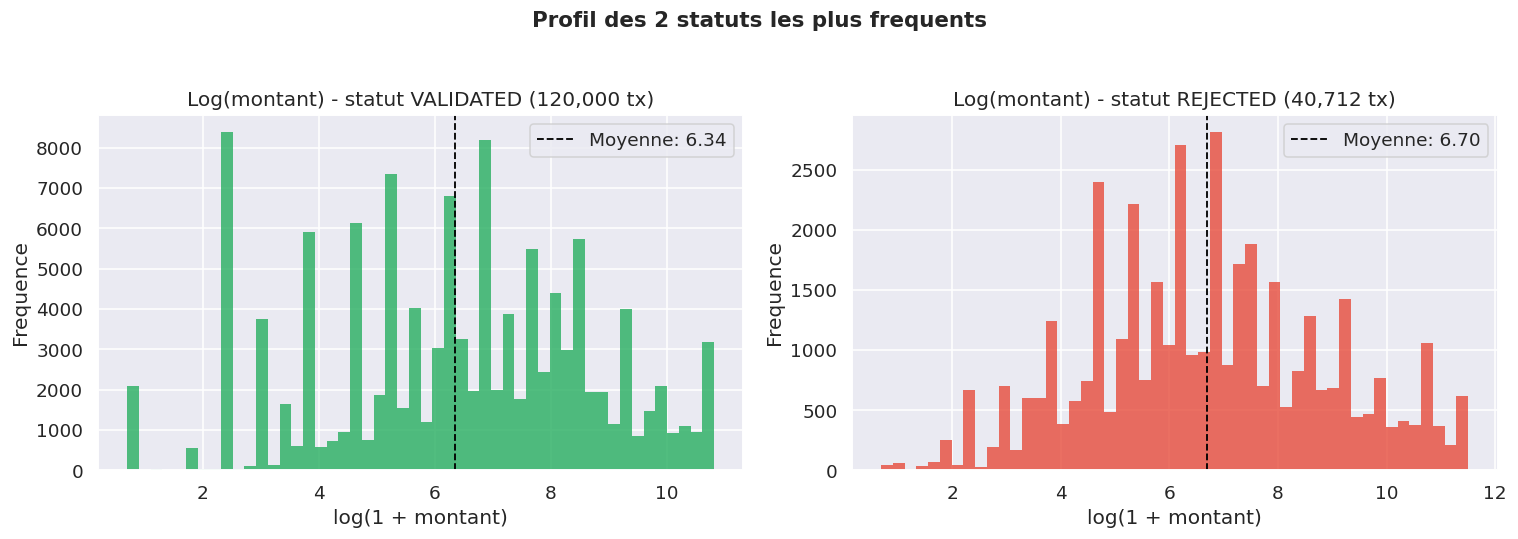

Statuts compares : VALIDATED, REJECTED


In [18]:
# Profil des 2 statuts les plus frequents
status_clean = (
    df_valid_num['TRANSACTION_STATUS']
    .fillna('UNKNOWN')
    .astype(str)
    .str.strip()
    .replace('', 'UNKNOWN')
)
top_status_for_compare = status_clean.value_counts().head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profil des 2 statuts les plus frequents', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes):
    if i >= len(top_status_for_compare):
        ax.axis('off')
        continue

    status = top_status_for_compare[i]
    color = '#27ae60' if i == 0 else '#e74c3c'
    subset = df_valid_num[status_clean == status]['AMOUNT_XOF'].dropna()

    if len(subset) == 0:
        ax.text(0.5, 0.5, f'Aucune donnee pour statut {status}', ha='center', va='center')
        ax.set_title(f'Statut {status}')
        continue

    if len(subset) > 120_000:
        subset = subset.sample(120_000, random_state=42)

    clipped = np.log1p(subset.clip(upper=subset.quantile(0.99), lower=0))
    ax.hist(clipped, bins=50, color=color, edgecolor='none', alpha=0.8)
    ax.set_title(f'Log(montant) - statut {status} ({len(subset):,} tx)')
    ax.set_xlabel('log(1 + montant)')
    ax.set_ylabel('Frequence')
    ax.axvline(clipped.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Moyenne: {clipped.mean():.2f}')
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../reports/figures/01_status_comparison.png', dpi=95)
plt.show()
plt.close(fig)

print('Statuts compares :', ', '.join(top_status_for_compare))


In [19]:
df_valid_num['TRANSACTION_STATUS'].value_counts(dropna=False)

TRANSACTION_STATUS
VALIDATED     430081
REJECTED       40712
INCOMPLETE     14085
REGISTERED      3245
EXPIRED           24
Name: count, dtype: int64

---
## 8. Synthèse & Recommandations Feature Engineering

### Observations clés

| Observation | Impact |
|---|---|
| Transactions nocturnes présentes | → Feature `tx_is_night` |
| Pics de volume sur certaines heures | → Features rolling 1h / 24h |
| Quelques expéditeurs avec très nombreux destinataires | → Feature `unique_dest_7d` (fan-out) |
| Montants proches des seuils 100k / 500k / 1M XOF | → Features `is_near_threshold_*` |
| Transactions à frais zéro sur montants élevés | → Feature `fee_ratio` |
| Certains codes service concentrent le volume | → Encoder `SERVICE_CODE` |

### Variables retenues pour le Feature Engineering
Voir **`02_Feature_Engineering.ipynb`** pour la construction complète des 18 features.

### Prochaine étape
```
02_Feature_Engineering.ipynb
  → 03_Isolation_Forest.ipynb  (scoring anomalie)
  → 04_Graph_Analysis.ipynb    (réseaux suspects)
  → 07_Explainability.ipynb    (SHAP + explications)
```


In [20]:
print("✅ EDA terminée.")
print(f"   Figures sauvegardées dans : ../reports/figures/")
print(f"   Fichiers créés :")
import os
figs = [f for f in os.listdir('../reports/figures') if f.startswith('01_')]
for f in sorted(figs):
    print(f"     {f}")


✅ EDA terminée.
   Figures sauvegardées dans : ../reports/figures/
   Fichiers créés :
     01_actors.png
     01_amounts.png
     01_categories.png
     01_correlation_raw.png
     01_missing_values.png
     01_status_comparison.png
     01_temporal.png
